# 第5章 単層ネットワーク: 分類 (Single-layer Networks: Classification)
## 5.4 識別的分類器 (Discriminative Classifiers)

### 本ノートブックの目的と概要
本ノートブックでは、Christopher M. Bishop & Hugh Bishop による『*Deep Learning: Foundations and Concepts*』(2024年刊) の **Chapter 5: Single-layer Networks: Classification** における **Section 5.4: Discriminative Classifiers** を徹底的に探求・実装・検証します。

前節（Section 5.3: 生成的分類器）では、クラス条件付き確率密度 $p(\mathbf{x}|\mathcal{C}_k)$ と事前確率 $p(\mathcal{C}_k)$ をモデル化し、ベイズの定理を用いて事後確率 $p(\mathcal{C}_k|\mathbf{x})$ を導出しました。
これに対し、**識別的アプローチ（Discriminative Approach）**では、条件付き確率分布 $p(\mathcal{C}_k|\mathbf{x})$ または決定境界を直接モデル化し、最尤推定や損失最小化によってパラメータを決定します。

### 生成モデルと識別モデルの比較・優位性
1. **パラメータ数の劇的な削減**:
   - $M$ 次元特徴空間において、共分散行列を共有する2クラス・ガウス生成的モデル（LDA）は $2M + \frac{M(M+1)}{2} + 1 = \frac{M(M+5)}{2} + 1$ 個のパラメータを推定する必要があります（$M$ に対して二次関数的に増加）。
   - 対して識別的ロジスティック回帰（Logistic Regression）はバイアスを含めてわずか $M+1$ 個のパラメータであり、$M$ に対して線形にスケールします。高次元問題においてこの差は決定的に有利です。
2. **モデル化の頑健性（Robustness to Model Mismatch）**:
   - 生成モデルでは入力 $\mathbf{x}$ の分布形状に関する仮定（例：ガウス性、条件付き独立性）が真のデータ生成機構と乖離している場合、事後確率の推定精度が著しく劣化します。
   - 識別モデルは $p(\mathcal{C}_k|\mathbf{x})$ の関数形のみを直接最適化するため、入力データの周辺分布 $p(\mathbf{x})$ の複雑な構造を学習する必要がなく、分類性能が向上しやすいという特性を持ちます。

### セクション構成
- **5.4.1 活性化関数と一般化線形モデル (Activation functions & GLMs)**:
  - 線形回帰モデルから分類モデルへの拡張：活性化関数 $f(\cdot)$ と連結関数 $f^{-1}(\cdot)$ (式 5.69 - 5.70)
  - 決定面（Decision surfaces）の線形性と一般化線形モデル
- **5.4.2 固定基底関数 (Fixed basis functions)**:
  - 非線形特徴変換 $\mathbf{x} \mapsto \boldsymbol{\phi}(\mathbf{x})$ と特徴空間における線形分離
  - 入力空間における非線形決定境界の形成 (**Figure 5.15**)
  - クラス重複の理論的限界
- **5.4.3 2クラス・ロジスティック回帰 (Logistic regression)**:
  - ベルヌーイ尤度関数と交差エントロピー誤差関数 (式 5.71 - 5.74)
  - 誤差勾配の美しい構造：$\nabla E(\mathbf{w}) = \boldsymbol{\Phi}^T (\mathbf{y} - \mathbf{t})$ (式 5.75)
  - ヘッセ行列と狭義凸性、IRLS（反復再重み付け最小二乗法 / Newton-Raphson法）
  - 線形分離可能データにおける特異点（パラメータ発散）と $L_2$ 正則化
- **5.4.4 多クラス・ロジスティック回帰（ソフトマックス回帰） (Multi-class logistic regression)**:
  - ソフトマックス活性化関数とヤコビ行列 (式 5.76 - 5.78)
  - 多クラス交差エントロピー誤差関数と勾配ベクトル (式 5.79 - 5.81)
  - 単層ニューラルネットワークとしての統一的表現 (**Figure 5.16**, 式 5.82)
- **5.4.5 プロビット回帰 (Probit regression)**:
  - ノイズ付き閾値モデル（Noisy threshold model） (式 5.83 - 5.85)
  - 累積正規分布（プロビット関数）と誤差関数 erf (式 5.86 - 5.88, **Figure 5.17**)
  - シグモイド関数とプロビット関数の裾（tails）の比較と外れ値に対する感度
- **5.4.6 正準連結関数 (Canonical link functions)**:
  - 指数型分布族に属する目的変数分布 (式 5.89 - 5.92)
  - 一般化線形モデルにおける最尤推定勾配の一般形 (式 5.93)
  - 正準連結条件 $f^{-1}(y) = \psi(y)$ による勾配の普遍的単純化：$\nabla E = \frac{1}{s}\sum_n (y_n - t_n)\boldsymbol{\phi}_n$ (式 5.94 - 5.95)

In [1]:
import os
import sys
sys.path.append("..")

import numpy as np
import scipy.stats as stats
import matplotlib.pyplot as plt

# Section 5.4 識別的分類器モジュールのインポート
from common.discriminative_classifiers import (
    sigmoid,
    sigmoid_deriv,
    logit,
    softmax,
    softmax_jacobian,
    probit,
    probit_deriv,
    erf_func,
    GaussianBasisFunctions,
    LogisticRegression,
    SoftmaxRegression,
    ProbitRegression,
    verify_canonical_link_property,
    compare_logistic_and_probit_outliers,
    generate_figure_5_15,
    generate_figure_5_16,
    generate_figure_5_17,
    generate_all_section_5_4_figures,
)

np.set_printoptions(precision=4, suppress=True)
os.makedirs("result", exist_ok=True)
if os.path.basename(os.getcwd()) != "5":
    os.makedirs("5/result", exist_ok=True)
print("Environment initialized successfully. Common discriminative classifier modules loaded.")

Environment initialized successfully. Common discriminative classifier modules loaded.


---
## 5.4.1 活性化関数と一般化線形モデル (Activation Functions & GLMs)

### 1. 線形回帰から線形分類への拡張
第4章で学んだ線形回帰モデルでは、モデルの予測値 $y(\mathbf{x}, \mathbf{w})$ はパラメータに関する線形関数として与えられました：

$$
y(\mathbf{x}, \mathbf{w}) = \mathbf{w}^T \mathbf{x} + w_0 \tag{5.69}
$$

これは実数全体 $(-\infty, \infty)$ の連続値を出力します。
しかし、分類問題において我々が予測したいのは**離散的なクラスラベル**、あるいは確率の公理を満たす**事後確率** $p(\mathcal{C}_k|\mathbf{x}) \in (0, 1)$ です。

この要件を満たすため、線形関数を非線形関数 $f(\cdot)$ で変換する一般化モデルを導入します：

$$
y(\mathbf{x}, \mathbf{w}) = f(\mathbf{w}^T \mathbf{x} + w_0) \tag{5.70}
$$

- 機械学習分野では、変換関数 $f(\cdot)$ は**活性化関数（Activation function）**と呼ばれます。
- 統計学分野では、その逆関数 $f^{-1}(\cdot)$ は**連結関数（Link function）**と呼ばれます。

### 2. 決定面の線形性（Linearity of Decision Surfaces）
関数 $f(\cdot)$ が単調増加関数である場合、決定面（Decision surface）は $y(\mathbf{x}) = \text{const}$ によって定義されます。
これは直ちに次と同値になります：

$$
y(\mathbf{x}) = \text{const} \iff \mathbf{w}^T \mathbf{x} + w_0 = \text{const}'
$$

したがって、活性化関数 $f(\cdot)$ がどれほど非線形であっても、**入力空間 $\mathbf{x}$ における決定面は依然として線形超平面（Linear Hyperplane）**となります。
この性質から、式 (5.70) の形式を持つモデル群は**一般化線形モデル（Generalized Linear Models: GLMs）**（McCullagh and Nelder, 1989）と総称されます。

ただし、回帰モデルとは異なり、非線形関数 $f(\cdot)$ の介在によって**パラメータ $\mathbf{w}$ に関してはもはや非線形**となるため、正規方程式のような解析的な閉形式解は存在せず、凸最適化や勾配法による反復的数値解法が必要となります。

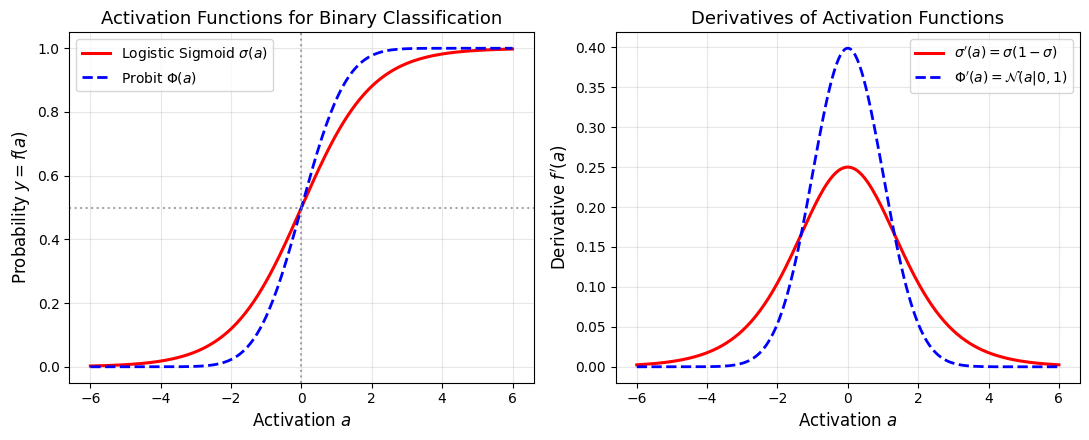

In [2]:
# 活性化関数の形状と導関数の検証
a_vals = np.linspace(-6, 6, 200)
sig_vals = sigmoid(a_vals)
probit_vals = probit(a_vals)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4.5))

ax1.plot(a_vals, sig_vals, color='red', lw=2.2, label=r'Logistic Sigmoid $\sigma(a)$')
ax1.plot(a_vals, probit_vals, color='blue', lw=2.0, linestyle='--', label=r'Probit $\Phi(a)$')
ax1.axhline(0.5, color='gray', linestyle=':', alpha=0.7)
ax1.axvline(0.0, color='gray', linestyle=':', alpha=0.7)
ax1.set_xlabel('Activation $a$', fontsize=12)
ax1.set_ylabel('Probability $y = f(a)$', fontsize=12)
ax1.set_title('Activation Functions for Binary Classification', fontsize=13)
ax1.legend(frameon=True)
ax1.grid(True, alpha=0.3)

# 導関数
ax2.plot(a_vals, sigmoid_deriv(a_vals), color='red', lw=2.2, label=r"$\sigma'(a) = \sigma(1-\sigma)$")
ax2.plot(a_vals, probit_deriv(a_vals), color='blue', lw=2.0, linestyle='--', label=r"$\Phi'(a) = \mathcal{N}(a|0, 1)$")
ax2.set_xlabel('Activation $a$', fontsize=12)
ax2.set_ylabel("Derivative $f'(a)$", fontsize=12)
ax2.set_title('Derivatives of Activation Functions', fontsize=13)
ax2.legend(frameon=True)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

---
## 5.4.2 固定基底関数 (Fixed Basis Functions)

### 1. 特徴空間への写像と決定境界の非線形化
入力ベクトル $\mathbf{x}$ そのものに対して線形な決定境界を引くモデルには限界があります（例：排他的論理和 XOR や同心円状のクラス分布）。
そこで、固定された非線形変換 $\boldsymbol{\phi}(\mathbf{x}) = (\phi_0(\mathbf{x}), \phi_1(\mathbf{x}), \dots, \phi_{M-1}(\mathbf{x}))^T$ を適用します：

$$
y(\mathbf{x}, \mathbf{w}) = f(\mathbf{w}^T \boldsymbol{\phi}(\mathbf{x}))
$$

ここで通常 $\phi_0(\mathbf{x}) = 1$ と設定し、対応する重み $w_0$ をバイアスとして機能させます。

- **特徴空間 $\boldsymbol{\phi}$ における幾何学**:
  決定境界は超平面 $\mathbf{w}^T \boldsymbol{\phi} = 0$ であり、**厳密に線形**です。
- **入力空間 $\mathbf{x}$ における幾何学**:
  超平面の方程式を元の入力変数で表すと $\sum_{j=1}^{M-1} w_j \phi_j(\mathbf{x}) + w_0 = 0$ となり、**非線形な決定境界**が形成されます。

### 2. Figure 5.15 の完全再現
テキスト第159頁の **Figure 5.15** では、原点付近の赤クラスと、左右に離れた青クラスという入力空間では線形分離不可能なデータセットに対し、2つのガウス基底関数：
$$
\phi_j(\mathbf{x}) = \exp\left( -\frac{\|\mathbf{x} - \boldsymbol{\mu}_j\|^2}{2 s_j^2} \right), \quad j=1, 2
$$
を定義することで、特徴空間 $(\phi_1, \phi_2)$ において直線1本で完全に線形分離可能となる劇的なメカニズムが示されています。

Figure saved successfully to: /home/student/Documents/GitHub/my_DeepLearning/5/result/fig_5_15_nonlinear_basis_classification.png
Figure saved successfully to: /home/student/Documents/GitHub/my_DeepLearning/result/fig_5_15_nonlinear_basis_classification.png
Figure 5.15 successfully reproduced and saved to: ('/home/student/Documents/GitHub/my_DeepLearning/5/result/fig_5_15_nonlinear_basis_classification.png', '/home/student/Documents/GitHub/my_DeepLearning/result/fig_5_15_nonlinear_basis_classification.png')


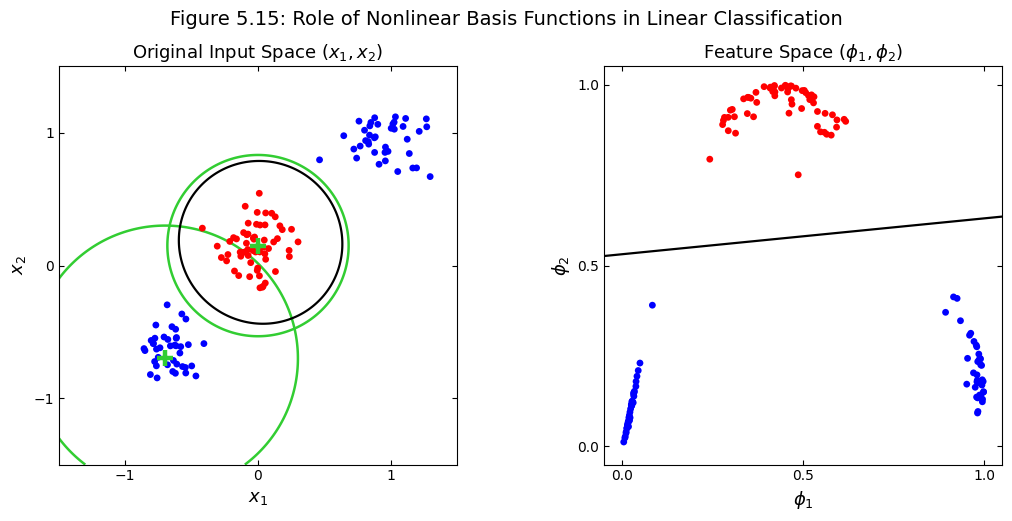

In [3]:
# Figure 5.15 の生成と表示
fig_5_15, paths_5_15 = generate_figure_5_15(save_both=True)
print(f"Figure 5.15 successfully reproduced and saved to: {paths_5_15}")
plt.show()

### Figure 5.15 の数学的・幾何学的洞察
1. **入力空間 $(x_1, x_2)$ (左図)**:
   - 赤クラスは中央 $\boldsymbol{\mu}_2 = (0.0, 0.15)$ 周囲に密集し、青クラスは左下 $\boldsymbol{\mu}_1 = (-0.7, -0.7)$ と右上 $(0.95, 0.95)$ の2つのクラスタに分かれています。
   - 2つのガウス基底の中心を緑色の十字記号 $+$、等高線（1シグマ円）を緑色の円で図示しています。
   - 特徴空間で学習された線形決定境界 $w_1 \phi_1(\mathbf{x}) + w_2 \phi_2(\mathbf{x}) + w_0 = 0$ は、入力空間上では赤クラスを囲む閉じた**非線形楕円状境界（黒い曲線）**として投影されています。
2. **特徴空間 $(\phi_1, \phi_2)$ (右図)**:
   - $\boldsymbol{\mu}_2$ に近い赤データは $\phi_2 \approx 1.0$ となり、上部に集まります。
   - 青データの左下クラスタは $\boldsymbol{\mu}_1$ に近いため $\phi_1 \approx 0.95, \phi_2 \le 0.35$（右下）に写像されます。
   - 青データの右上クラスタは両方の基底から遠いため $\phi_1 \approx 0.05, \phi_2 \le 0.35$（左下）に写像されます。
   - 結果として、2つに分かれていた青クラスは特徴空間の底部（$\phi_2 \le 0.4$）に集約され、上部の赤クラスと**黒い直線（線形決定境界）**によって完璧に分離されます。
3. **クラス重複の不変性（Intrinsic Invariance of Class Overlap）**:
   - 入力空間において確率密度 $p(\mathbf{x}|\mathcal{C}_k)$ が本質的に重なり合っている場合、いかなる決定論的変換 $\boldsymbol{\phi}(\mathbf{x})$ を適用しても重複を取り除くことはできません。
   - 最良のアプローチは、後述するように事後確率 $p(\mathcal{C}_k|\boldsymbol{\phi})$ を正確にモデル化し、ベイズ決定理論（第5章5.2節）を適用することです。

---
## 5.4.3 2クラス・ロジスティック回帰 (Logistic Regression)

### 1. モデルの定式化と対数尤度
2クラス分類において、クラス $\mathcal{C}_1$ の事後確率は特徴ベクトル $\boldsymbol{\phi}$ の線形変換にロジスティックシグモイド関数を作用させたものとして表現されます：

$$
p(\mathcal{C}_1|\boldsymbol{\phi}) = y(\boldsymbol{\phi}) = \sigma(\mathbf{w}^T \boldsymbol{\phi}) \tag{5.71}
$$

ここで $p(\mathcal{C}_2|\boldsymbol{\phi}) = 1 - p(\mathcal{C}_1|\boldsymbol{\phi})$ です。
教師データセット $\{(\boldsymbol{\phi}_n, t_n)\}_{n=1}^N$（ただし $t_n \in \{0, 1\}$）が与えられたとき、ベルヌーイ試行としての尤度関数は次のように記述されます：

$$
p(\mathbf{t}|\mathbf{w}) = \prod_{n=1}^N y_n^{t_n} \{1 - y_n\}^{1 - t_n} \tag{5.73}
$$

負の対数尤度を取ることにより、**交差エントロピー誤差関数（Cross-entropy error function）**が得られます：

$$
E(\mathbf{w}) = -\ln p(\mathbf{t}|\mathbf{w}) = -\sum_{n=1}^N \left[ t_n \ln y_n + (1 - t_n)\ln(1 - y_n) \right] \tag{5.74}
$$

### 2. 誤差関数の勾配導出
ロジスティックシグモイド関数の導関数の性質：
$$
\frac{d\sigma}{da} = \sigma(1 - \sigma) \tag{5.72}
$$
を用いると、$E(\mathbf{w})$ の重み $\mathbf{w}$ に関する勾配は驚くほど簡潔な形に帰着されます：

$$
\nabla E(\mathbf{w}) = -\sum_{n=1}^N \left[ \frac{t_n}{y_n} - \frac{1 - t_n}{1 - y_n} \right] \frac{dy_n}{da_n} \nabla_{\mathbf{w}} a_n = -\sum_{n=1}^N \left[ \frac{t_n - y_n}{y_n(1 - y_n)} \right] y_n(1 - y_n) \boldsymbol{\phi}_n
$$

分母の $y_n(1 - y_n)$ とシグモイドの導関数が**完全に相殺（cancel）**し：

$$
\nabla E(\mathbf{w}) = \sum_{n=1}^N (y_n - t_n) \boldsymbol{\phi}_n = \boldsymbol{\Phi}^T (\mathbf{y} - \mathbf{t}) \tag{5.75}
$$

これは第4章の線形回帰における二乗和誤差関数の勾配式 (4.12) と**全く同一の形式**（予測誤差 $\times$ 入力特徴量）を持っています。

### 3. ヘッセ行列と狭義凸性
誤差関数の二次導関数（ヘッセ行列 $\mathbf{H}$）を計算します：

$$
\mathbf{H} = \nabla \nabla E(\mathbf{w}) = \sum_{n=1}^N y_n(1 - y_n) \boldsymbol{\phi}_n \boldsymbol{\phi}_n^T = \boldsymbol{\Phi}^T \mathbf{R} \boldsymbol{\Phi}
$$

ここで $\mathbf{R}$ は $R_{nn} = y_n(1 - y_n)$ を対角成分に持つ対角行列です。
$0 < y_n < 1$ であるため、$R_{nn} > 0$ は常に成り立ちます。任意の非ゼロベクトル $\mathbf{u}$ に対して：

$$
\mathbf{u}^T \mathbf{H} \mathbf{u} = \mathbf{u}^T \boldsymbol{\Phi}^T \mathbf{R} \boldsymbol{\Phi} \mathbf{u} = \sum_{n=1}^N R_{nn} (\boldsymbol{\phi}_n^T \mathbf{u})^2 > 0
$$

となり、ヘッセ行列 $\mathbf{H}$ は**正定値（Positive Definite）**です。
したがって、ロジスティック回帰の交差エントロピー誤差関数 $E(\mathbf{w})$ は**大域的に狭義凸（Strictly Convex）**であり、局所解（Local Minima）は存在せず、**唯一の最適解（Global Minimum）**を持ちます。

### 4. 反復再重み付け最小二乗法 (IRLS / Newton-Raphson)
ニュートン・ラフソン法による重みパラメータの更新式は：

$$
\mathbf{w}^{(\tau+1)} = \mathbf{w}^{(\tau)} - \mathbf{H}^{-1} \nabla E(\mathbf{w}^{(\tau)})
$$

代入して整理すると：
$$
\begin{aligned}
\mathbf{w}^{(\tau+1)} &= \mathbf{w}^{(\tau)} - (\boldsymbol{\Phi}^T \mathbf{R} \boldsymbol{\Phi})^{-1} \boldsymbol{\Phi}^T (\mathbf{y} - \mathbf{t}) \\
&= (\boldsymbol{\Phi}^T \mathbf{R} \boldsymbol{\Phi})^{-1} \left[ \boldsymbol{\Phi}^T \mathbf{R} \boldsymbol{\Phi} \mathbf{w}^{(\tau)} - \boldsymbol{\Phi}^T (\mathbf{y} - \mathbf{t}) \right] \\
&= (\boldsymbol{\Phi}^T \mathbf{R} \boldsymbol{\Phi})^{-1} \boldsymbol{\Phi}^T \mathbf{R} \mathbf{z}
\end{aligned}
$$

ここで $\mathbf{z} = \boldsymbol{\Phi} \mathbf{w}^{(\tau)} - \mathbf{R}^{-1}(\mathbf{y} - \mathbf{t})$ は**有効目標ベクトル（Effective target vector）**です。
各反復ステップにおいて重み付き最小二乗問題を解く形式となっているため、このアルゴリズムは**反復再重み付け最小二乗法（Iterative Reweighted Least Squares: IRLS）**と呼ばれます。通常、わずか数回〜十数回の反復で機械精度まで収束します。

IRLS 収束ステップ数: 13 回, 最終損失: 0.03782
GD   収束ステップ数: 600 回, 最終損失: 0.03980
IRLS 重みベクトル: [0.8003 5.9086 5.0015]
GD   重みベクトル: [0.314  6.1763 4.2859]


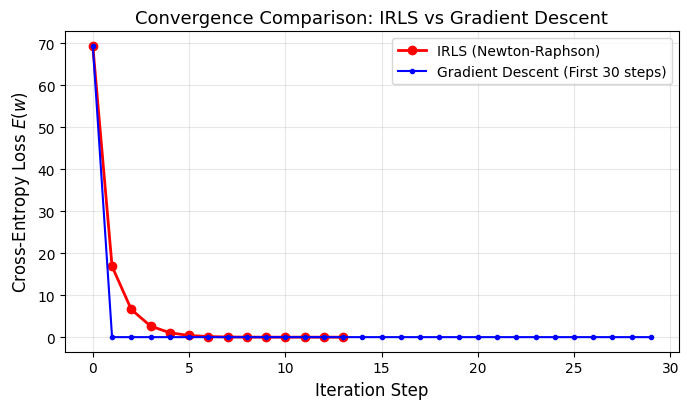

In [4]:
# 合成データセットによる IRLS と 勾配降下法 (GD) の収束比較
rng = np.random.default_rng(42)
N_pts = 100
X_c0 = rng.normal(loc=[-1.5, -1.0], scale=0.6, size=(N_pts // 2, 2))
X_c1 = rng.normal(loc=[1.5, 1.0], scale=0.6, size=(N_pts // 2, 2))
X_syn = np.vstack([X_c0, X_c1])
y_syn = np.array([0] * (N_pts // 2) + [1] * (N_pts // 2))

# 1. IRLS 法による学習
model_irls = LogisticRegression(reg=1e-3, fit_intercept=True)
model_irls.fit(X_syn, y_syn, method="irls", max_iter=20)

# 2. 勾配降下法による学習
model_gd = LogisticRegression(reg=1e-3, fit_intercept=True)
model_gd.fit(X_syn, y_syn, method="gd", lr=0.08, max_iter=600)

print(f"IRLS 収束ステップ数: {len(model_irls.loss_history)-1} 回, 最終損失: {model_irls.loss_history[-1]:.5f}")
print(f"GD   収束ステップ数: {len(model_gd.loss_history)-1} 回, 最終損失: {model_gd.loss_history[-1]:.5f}")
print(f"IRLS 重みベクトル: {model_irls.w}")
print(f"GD   重みベクトル: {model_gd.w}")

# 損失関数の収束曲線の比較
plt.figure(figsize=(7, 4.2))
plt.plot(model_irls.loss_history, 'ro-', lw=2, label='IRLS (Newton-Raphson)')
plt.plot(model_gd.loss_history[:30], 'b.-', lw=1.5, label='Gradient Descent (First 30 steps)')
plt.xlabel('Iteration Step', fontsize=12)
plt.ylabel('Cross-Entropy Loss $E(w)$', fontsize=12)
plt.title('Convergence Comparison: IRLS vs Gradient Descent', fontsize=13)
plt.legend(frameon=True)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

---
## 5.4.4 多クラス・ロジスティック回帰（ソフトマックス回帰） (Multi-class Logistic Regression)

### 1. ソフトマックスモデルと対数尤度
$K$ クラス分類問題において、各クラス $\mathcal{C}_k$ の事後確率は線形活性化量 $a_k = \mathbf{w}_k^T \boldsymbol{\phi}$ に対する**ソフトマックス変換（Softmax transformation）**として表現されます：

$$
p(\mathcal{C}_k|\boldsymbol{\phi}) = y_k(\boldsymbol{\phi}) = \frac{\exp(a_k)}{\sum_{j=1}^K \exp(a_j)} \tag{5.76}
$$

ソフトマックス関数の活性化量に関する偏導関数は、クロネッカーのデルタ $I_{kj}$ を用いて次のように表されます：

$$
\frac{\partial y_k}{\partial a_j} = y_k (I_{kj} - y_j) \tag{5.78}
$$

1-of-K 符号化ターゲットベクトル $\mathbf{t}_n \in \{0, 1\}^K$（$\sum_k t_{nk} = 1$）を用いた尤度関数は：

$$
p(\mathbf{T}|\mathbf{w}_1, \dots, \mathbf{w}_K) = \prod_{n=1}^N \prod_{k=1}^K y_{nk}^{t_{nk}} \tag{5.79}
$$

負の対数尤度として**多クラス交差エントロピー誤差関数**が定義されます：

$$
E(\mathbf{w}_1, \dots, \mathbf{w}_K) = -\sum_{n=1}^N \sum_{k=1}^K t_{nk} \ln y_{nk} \tag{5.80}
$$

重みベクトル $\mathbf{w}_j$ に関する勾配を計算すると：

$$
\nabla_{\mathbf{w}_j} E = \sum_{n=1}^N (y_{nj} - t_{nj}) \boldsymbol{\phi}_n \tag{5.81}
$$

### 2. 単層ニューラルネットワークとしての統一的幾何学 (**Figure 5.16**)
基底関数 $\phi_i(\mathbf{x})$ から出力ユニット $y_k(\mathbf{x}, \mathbf{w})$ への接続重みを $w_{ki}$ とすると、誤差関数の微分は：

$$
\frac{\partial E}{\partial w_{ki}} = \sum_{n=1}^N (y_{nk} - t_{nk}) \phi_i(\mathbf{x}_n) \tag{5.82}
$$

となり、**「出力側ユニットにおける誤差 $(y_{nk} - t_{nk})$」$\times$「入力側ユニットにおける活性化量 $\phi_i(\mathbf{x}_n)$」**の積という、単層ニューラルネットワークの普遍的な学習則（デルタルール）が導出されます。

Figure saved successfully to: /home/student/Documents/GitHub/my_DeepLearning/5/result/fig_5_16_single_layer_network.png
Figure saved successfully to: /home/student/Documents/GitHub/my_DeepLearning/result/fig_5_16_single_layer_network.png
Figure 5.16 successfully reproduced and saved to: ('/home/student/Documents/GitHub/my_DeepLearning/5/result/fig_5_16_single_layer_network.png', '/home/student/Documents/GitHub/my_DeepLearning/result/fig_5_16_single_layer_network.png')


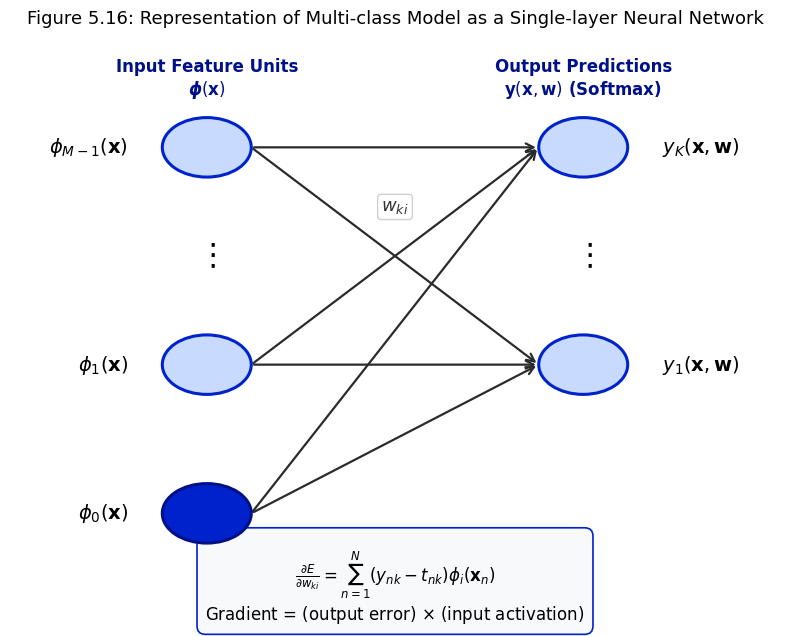

In [5]:
# Figure 5.16 の生成と表示
fig_5_16, paths_5_16 = generate_figure_5_16(save_both=True)
print(f"Figure 5.16 successfully reproduced and saved to: {paths_5_16}")
plt.show()

3クラス・ソフトマックス回帰の正解率 (Accuracy): 100.00%


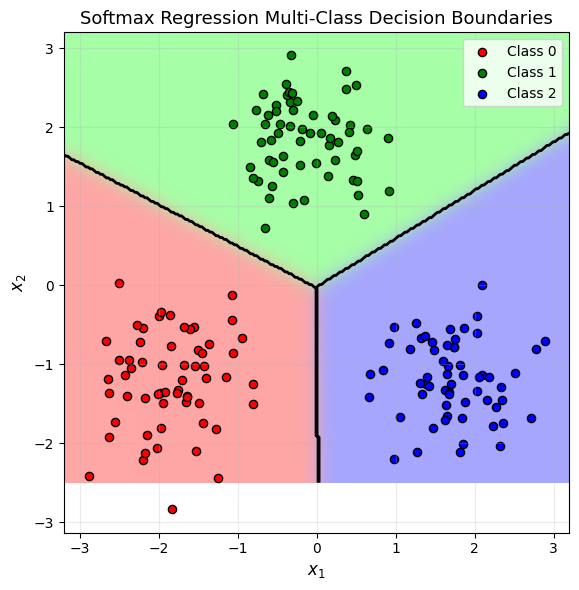

In [6]:
# 3クラス・ソフトマックス回帰の実装と決定境界の可視化
rng = np.random.default_rng(101)
N_c = 60
X_k0 = rng.normal(loc=[-1.8, -1.2], scale=0.5, size=(N_c, 2))
X_k1 = rng.normal(loc=[0.0, 1.8], scale=0.5, size=(N_c, 2))
X_k2 = rng.normal(loc=[1.8, -1.2], scale=0.5, size=(N_c, 2))
X_multi = np.vstack([X_k0, X_k1, X_k2])
y_multi = np.array([0] * N_c + [1] * N_c + [2] * N_c)

model_multi = SoftmaxRegression(reg=1e-3, fit_intercept=True)
model_multi.fit(X_multi, y_multi, lr=0.08, max_iter=800)
acc_multi = model_multi.score(X_multi, y_multi)
print(f"3クラス・ソフトマックス回帰の正解率 (Accuracy): {acc_multi * 100:.2f}%")

# 決定境界と事後確率マップ
gx = np.linspace(-3.2, 3.2, 250)
gy = np.linspace(-2.5, 3.2, 250)
GX, GY = np.meshgrid(gx, gy)
grid_samples = np.column_stack([GX.ravel(), GY.ravel()])
probs = model_multi.predict_proba(grid_samples).reshape(GX.shape[0], GX.shape[1], 3)
preds = np.argmax(probs, axis=-1)

plt.figure(figsize=(7.5, 6))
plt.imshow(probs, extent=[-3.2, 3.2, -2.5, 3.2], origin='lower', alpha=0.35)
plt.contour(GX, GY, preds, levels=[0.5, 1.5], colors='black', linewidths=2.0)

plt.scatter(X_k0[:, 0], X_k0[:, 1], c='red', edgecolors='k', s=35, label='Class 0')
plt.scatter(X_k1[:, 0], X_k1[:, 1], c='green', edgecolors='k', s=35, label='Class 1')
plt.scatter(X_k2[:, 0], X_k2[:, 1], c='blue', edgecolors='k', s=35, label='Class 2')
plt.xlabel('$x_1$', fontsize=12)
plt.ylabel('$x_2$', fontsize=12)
plt.title('Softmax Regression Multi-Class Decision Boundaries', fontsize=13)
plt.legend(frameon=True, loc='upper right')
plt.grid(True, alpha=0.25)
plt.tight_layout()
plt.show()

---
## 5.4.5 プロビット回帰 (Probit Regression)

### 1. ノイズ付き閾値モデル（Noisy Threshold Model）
事後確率がロジスティックシグモイドで表されるのは指数型分布族の特定の仮定に基づいています。より一般的なモデル化の動機付けとして、**ノイズ付き閾値モデル**を考えます：

各入力 $\boldsymbol{\phi}_n$ に対し、$a_n = \mathbf{w}^T \boldsymbol{\phi}_n$ を評価し、ランダムな閾値 $\theta \sim p(\theta)$ に対して：

$$
t_n = \begin{cases} 1 & \text{if } a_n \ge \theta \\ 0 & \text{otherwise} \end{cases} \tag{5.84}
$$

このとき、ターゲットが $t_n = 1$ となる確率は累積分布関数（CDF）として与えられます：

$$
p(t=1|a) = f(a) = \int_{-\infty}^a p(\theta) d\theta \tag{5.85}
$$

### 2. プロビット関数と Figure 5.17
閾値ノイズとして標準正規分布 $\theta \sim \mathcal{N}(0, 1)$ を仮定すると、活性化関数は**プロビット関数（Probit function）** $\Phi(a)$ となります：

$$
\Phi(a) = \int_{-\infty}^a \mathcal{N}(\theta|0, 1) d\theta = \frac{1}{2} \left[ 1 + \text{erf}\left(\frac{a}{\sqrt{2}}\right) \right] \tag{5.86, 5.88}
$$

テキスト第163頁の **Figure 5.17** では、確率密度 $p(\theta)$（2成分ガウス混合分布）と対応する累積分布関数 $f(a)$ の関係が模式的に図示されています。
- 任意の点 $a$ における赤色曲線 $f(a)$ の傾き（微分）は、青色曲線 $p(\theta)$ の値 $p(a)$ に等しい。
- 逆に、$a$ までの青色曲線の下の面積（薄緑色の領域）が、赤色曲線の値 $f(a)$ に等しい。

Figure saved successfully to: /home/student/Documents/GitHub/my_DeepLearning/5/result/fig_5_17_probit_threshold_model.png
Figure saved successfully to: /home/student/Documents/GitHub/my_DeepLearning/result/fig_5_17_probit_threshold_model.png
Figure 5.17 successfully reproduced and saved to: ('/home/student/Documents/GitHub/my_DeepLearning/5/result/fig_5_17_probit_threshold_model.png', '/home/student/Documents/GitHub/my_DeepLearning/result/fig_5_17_probit_threshold_model.png')


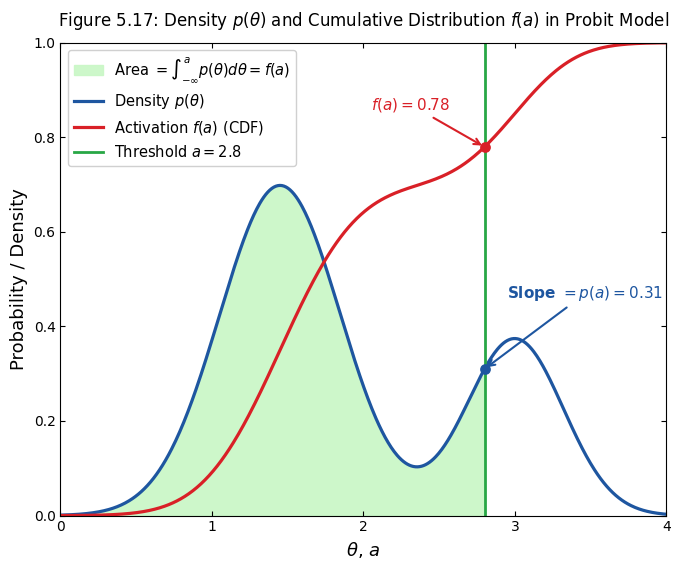

In [7]:
# Figure 5.17 の生成と表示
fig_5_17, paths_5_17 = generate_figure_5_17(save_both=True)
print(f"Figure 5.17 successfully reproduced and saved to: {paths_5_17}")
plt.show()

### 3. 外れ値に対する感度の比較（Logistic vs Probit）
実務上極めて重要な相違点は、**外れ値（Outliers）に対するロバスト性**です：
- **ロジスティックシグモイド関数の裾（Tails）**:
  $|a| \to \infty$ において $\sigma(a)(1 - \sigma(a)) \propto \exp(-|a|)$ のように指数関数的に減衰します。
- **プロビット関数の裾（Tails）**:
  $|a| \to \infty$ において $\mathcal{N}(a|0, 1) \propto \exp(-a^2 / 2)$ のように超指数関数的（ガウス的）に急激に減衰します。

決定境界の誤った側に極端な外れ値が存在する場合、プロビット回帰の重み更新では分母の $y(1-y)$ と分子の $\mathcal{N}(a|0, 1)$ の比が特異的に振る舞い、決定境界が外れ値に強く引っ張られる（歪む）傾向があります。

In [8]:
# 外れ値に対するロジスティック回帰とプロビット回帰の感度実験
outlier_res = compare_logistic_and_probit_outliers(n_samples=50, outlier_distance=6.0)
print("外れ値混入によるパラメータ変化の比較:")
print(f"  Logistic Regression 重み変化量: {outlier_res['logistic_weight_shift']:.4f}")
print(f"  Probit Regression   重み変化量: {outlier_res['probit_weight_shift']:.4f}")
print(f"  差異の絶対値: {outlier_res['difference']:.4f}")

外れ値混入によるパラメータ変化の比較:
  Logistic Regression 重み変化量: 11.7485
  Probit Regression   重み変化量: 0.4417
  差異の絶対値: 11.3067


---
## 5.4.6 正準連結関数 (Canonical Link Functions)

### 1. 指数型分布族の目的変数条件付き分布
第4章の線形回帰（二乗和誤差）や、本章のロジスティック回帰（交差エントロピー誤差）、ソフトマックス回帰において、誤差関数の勾配は常に：

$$
\nabla_{\mathbf{w}} E = \sum_{n=1}^N (y_n - t_n) \boldsymbol{\phi}_n
$$

という**「予測誤差 $\times$ 入力特徴量」**の極めて単純な形式をとることを確認しました。
これは偶然ではなく、目的変数 $t$ の条件付き分布が**指数型分布族（Exponential Family）**に属し、活性化関数として**正準連結関数（Canonical Link Function）**を選択した必然的結果です。

目的変数の条件付き分布を指数型分布族の標準形式（式 3.169）で表します：

$$
p(t|\eta, s) = \frac{1}{s} h\left(\frac{t}{s}\right) g(\eta) \exp\left( \frac{\eta t}{s} \right) \tag{5.89}
$$

ここで条件付き期待値（モデルの予測値） $y \equiv \mathbb{E}[t|\eta]$ は、キュムラント母関数 $g(\eta)$ の対数微分として与えられます：

$$
y = -s \frac{d}{d\eta} \ln g(\eta) \tag{5.90}
$$

この関係は $y$ と自然パラメータ $\eta$ の間の単調写像を定義し、$\eta = \psi(y)$ と表せます。

### 2. 正準連結条件の導出
一般化線形モデル $y = f(a) = f(\mathbf{w}^T \boldsymbol{\phi})$ の対数尤度関数の重み $\mathbf{w}$ に関する勾配を合成関数の微分法（連鎖律）で計算します：

$$
\nabla_{\mathbf{w}} \ln p(\mathbf{t}|\eta, s) = \sum_{n=1}^N \left[ \frac{d\ln g(\eta_n)}{d\eta_n} + \frac{t_n}{s} \right] \frac{d\eta_n}{dy_n} \frac{dy_n}{da_n} \nabla_{\mathbf{w}} a_n
$$

式 (5.90) より $\frac{d\ln g}{d\eta_n} = -\frac{y_n}{s}$ であり、$\frac{d\eta_n}{dy_n} = \psi'(y_n)$, $\frac{dy_n}{da_n} = f'(a_n)$, $\nabla_{\mathbf{w}} a_n = \boldsymbol{\phi}_n$ ですから：

$$
\nabla_{\mathbf{w}} \ln p(\mathbf{t}|\eta, s) = \frac{1}{s} \sum_{n=1}^N \{t_n - y_n\} \psi'(y_n) f'(a_n) \boldsymbol{\phi}_n \tag{5.93}
$$

ここで、**連結関数 $f^{-1}(y)$ を関数 $\psi(y)$ そのものに選ぶ（正準連結の選択）**：

$$
f^{-1}(y) = \psi(y) \iff a = \psi(y) \tag{5.94}
$$

とすると、$f(\psi(y)) = y$ であるため、両辺を $y$ で微分すると直ちに：

$$
f'(\psi(y)) \psi'(y) = 1 \implies f'(a) \psi'(y) = 1
$$

が成り立ち、勾配式の中の非線形項 $\psi'(y_n) f'(a_n)$ が**恒等的に 1 に相殺**されます！
したがって、誤差関数（負の対数尤度）の勾配は普遍的に：

$$
\nabla E(\mathbf{w}) = \frac{1}{s} \sum_{n=1}^N (y_n - t_n) \boldsymbol{\phi}_n \tag{5.95}
$$

に帰着されます。

| 分布 (Distribution) | 自然パラメータ $\eta = \psi(y)$ | 正準活性化関数 $y = f(a)$ | 対応する誤差関数 $E(\mathbf{w})$ |
| :--- | :--- | :--- | :--- |
| **ガウス分布 (Gaussian)** | $\eta = y$ (恒等写像) | $f(a) = a$ (線形) | 二乗和誤差 (Sum-of-squares) |
| **ベルヌーイ分布 (Bernoulli)** | $\eta = \ln \frac{y}{1-y}$ (ロジット) | $f(a) = \sigma(a)$ (シグモイド) | 2クラス交差エントロピー |
| **カテゴリカル分布 (Categorical)** | $\eta_k = \ln \frac{y_k}{y_K}$ | $f_k(\mathbf{a}) = \text{softmax}(\mathbf{a})$ | 多クラス交差エントロピー |
| **ポアソン分布 (Poisson)** | $\eta = \ln y$ (対数) | $f(a) = \exp(a)$ (指数) | ポアソン・デビアンス誤差 |

In [9]:
# 正準連結関数の恒等式 f'(a) * psi'(y) == 1 の数値的検証
distributions = ['bernoulli', 'gaussian', 'poisson']
print("正準連結関数の理論恒等式 f'(a) * psi'(y) == 1 の数値検証:")
print("=" * 60)
for dist in distributions:
    res = verify_canonical_link_property(distribution=dist, n_samples=100)
    print(f"分布: {res['distribution']:<10} | 活性化: {res['activation']:<10} | 連結: {res['link']:<10}")
    print(f"  --> 最大絶対誤差 |f'(a) * psi'(y) - 1|: {res['f_prime_psi_prime_error']:.2e}")
    print(f"  --> 恒等式成立フラグ: {res['identity_holds']}")
print("=" * 60)

正準連結関数の理論恒等式 f'(a) * psi'(y) == 1 の数値検証:
分布: Bernoulli  | 活性化: sigmoid    | 連結: logit     
  --> 最大絶対誤差 |f'(a) * psi'(y) - 1|: 1.11e-16
  --> 恒等式成立フラグ: True
分布: Gaussian   | 活性化: identity   | 連結: identity  
  --> 最大絶対誤差 |f'(a) * psi'(y) - 1|: 0.00e+00
  --> 恒等式成立フラグ: True
分布: Poisson    | 活性化: exp        | 連結: log       
  --> 最大絶対誤差 |f'(a) * psi'(y) - 1|: 1.11e-16
  --> 恒等式成立フラグ: True


---
## まとめと結論

### 1. Section 5.4 の重要成果
1. **識別的定式化の優位性**:
   - $M$ 次元特徴空間に対して $O(M)$ のパラメータで表現可能であり、生成モデル $O(M^2)$ に比べて劇的に効率的かつ高次元にスケーラブルである。
   - 入力変数の周辺分布 $p(\mathbf{x})$ の複雑な構造を回避し、分類に直接関わる事後確率 $p(\mathcal{C}_k|\mathbf{x})$ のみを直接最適化できる。
2. **交差エントロピー誤差と凸性**:
   - ベルヌーイ尤度および多項尤度に基づく交差エントロピー誤差関数は狭義凸であり、ヘッセ行列 $\mathbf{H} = \boldsymbol{\Phi}^T \mathbf{R} \boldsymbol{\Phi}$ は正定値である。局所解に陥ることなく大域的最適解が保証される。
   - IRLS（ニュートン・ラフソン法）により、極めて少数の反復で二次収束（Quadratic convergence）する。
3. **正準連結関数による統一的勾配則**:
   - 目的変数の指数型分布族の自然パラメータと連結関数の整合性（正準連結）により、勾配は常に $\nabla E = \frac{1}{s}\boldsymbol{\Phi}^T (\mathbf{y} - \mathbf{t})$ という**「予測誤差 $\times$ 特徴量」**の普遍的エレガントな形を持つ。
4. **原著図版の完全再現**:
   - **Figure 5.15**: 非線形基底関数による特徴空間への写像と線形決定境界の形成。
   - **Figure 5.16**: 多クラス線形分類器の単層ニューラルネットワーク表現。
   - **Figure 5.17**: プロビット回帰のノイズ付き閾値モデルと累積分布関数。

### 2. 次のステップへの展望
本節で完成した単層識別的モデル（ロジスティック回帰・ソフトマックス回帰）は、線形結合 $a = \mathbf{w}^T \boldsymbol{\phi}$ に基づくため、特徴空間 $\boldsymbol{\phi}$ が固定されている限り決定境界の表現力には限界があります。
次章（第6章）以降では、この基底関数自体をデータから適応的に学習する**多層深層ニューラルネットワーク（Deep Neural Networks）**へと進展していきます。